## TS2: Modelizando un ADC



En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de B bits en un rango de  ±VF
 Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a fs Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

frecuencia f0
 arbitraria, por ejemplo f0=fS/N=Δf
 
energía normalizada, es decir energía (o varianza) unitaria
Con respecto a los parámetros de la secuencia de ruido, diremos que:

será de carácter aditivo, es decir la señal que entra al ADC será sR=s+n
. Siendo n
 la secuencia que simula la interferencia, y s
 la senoidal descrita anteriormente.
La potencia del ruido será Pn=kn.Pq
 W siendo el factor k una escala para la potencia del ruido de cuantización Pq=q212
.
finalmente, n
 será incorrelado y Gaussiano.
El ADC que deseamos simular trabajará a una frecuencia de muestreo fS=1000
 Hz y tendrá un rango analógico de ±VF=2
 Volts.


Se pide:

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1

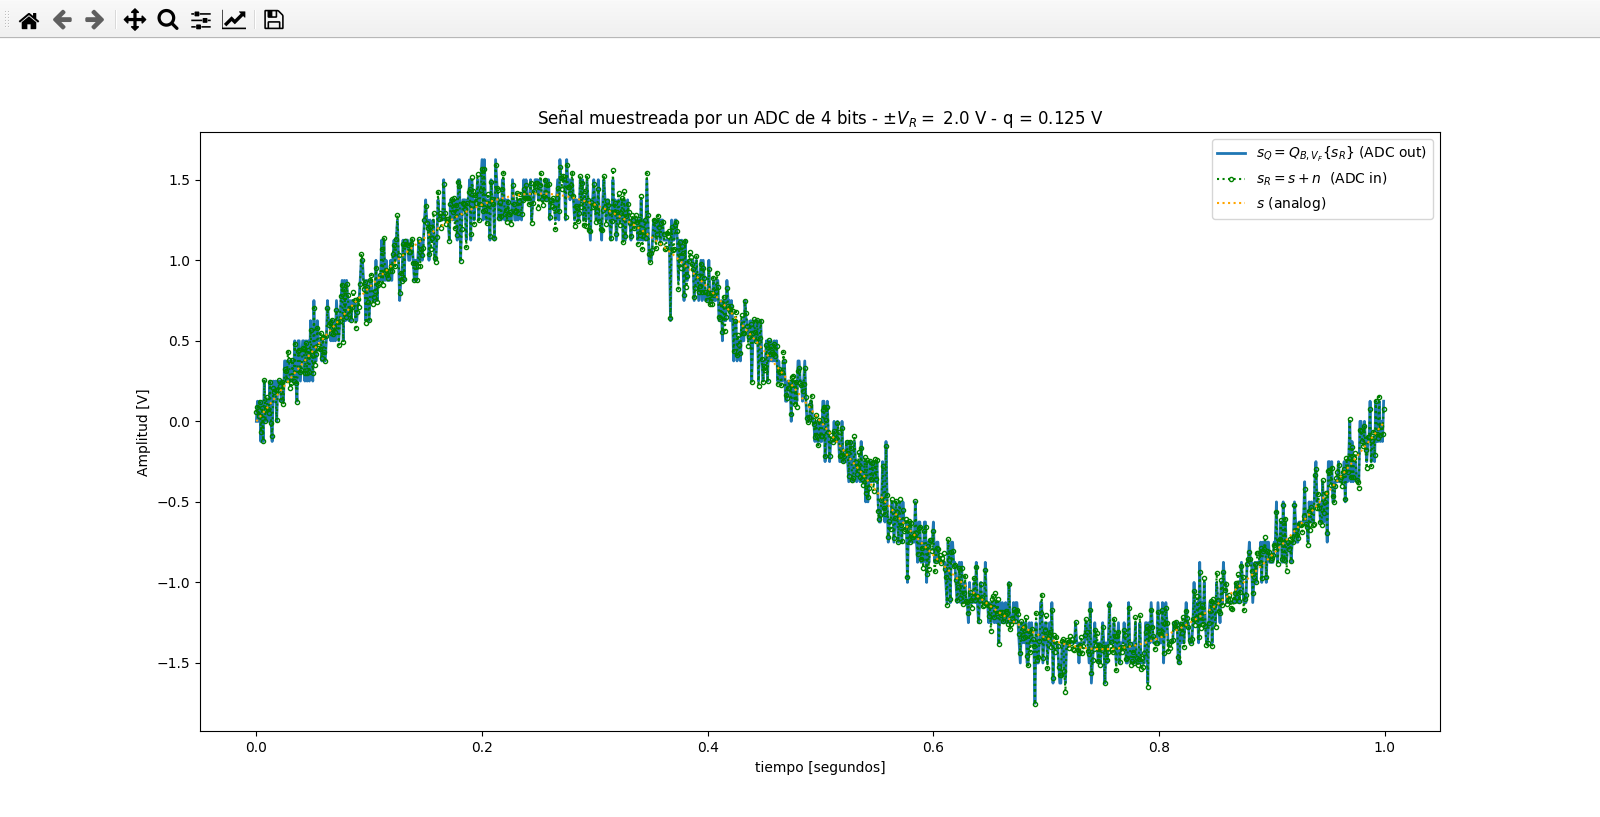

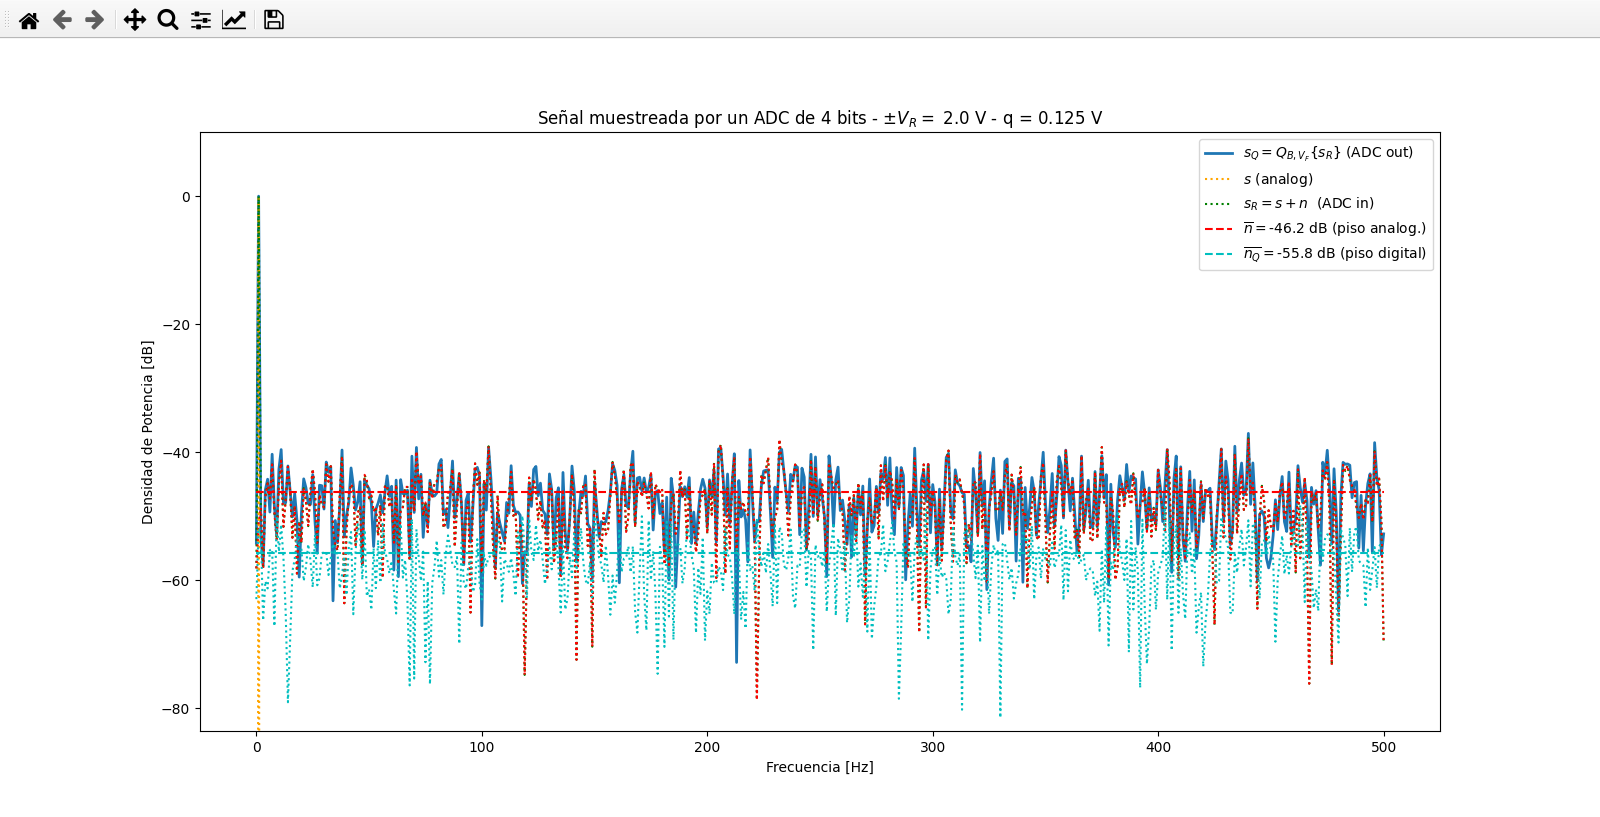

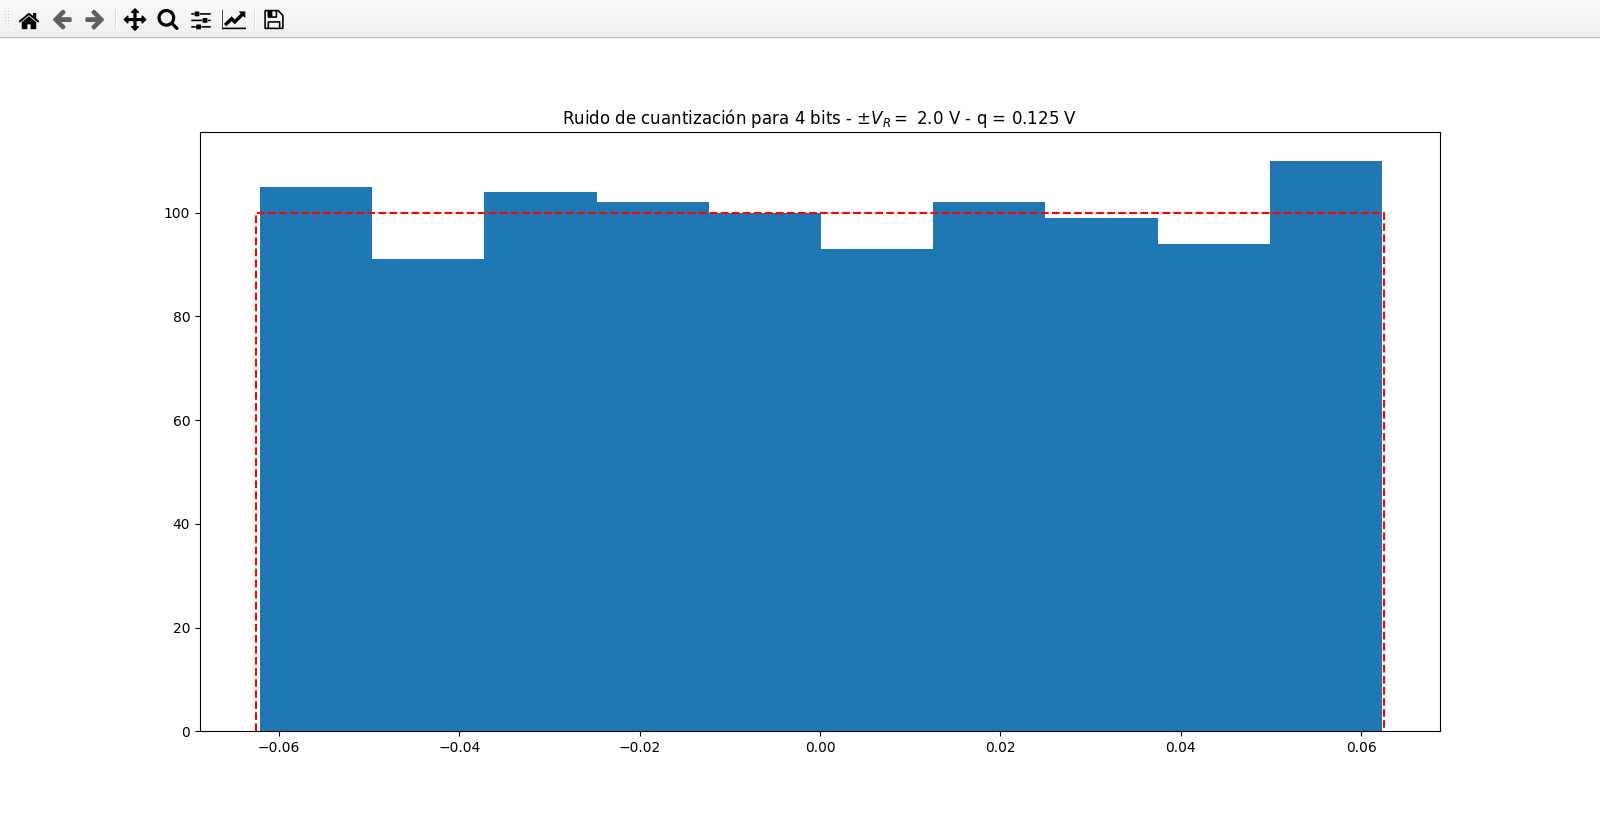

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

# params
fs = 1000.0
N = 1000
f0 = fs / N 
V_F = 2.0 
B = 4 
kn = 1.0 

# paso de cuantizacion q
q = (2 * V_F) / (2**B)  # me da 0.25
#q=0.125 usado en los graficos de ej

# potencia teorica del ruido de cuantizacion y ruido analogico
Pq = (q**2) / 12
Pn = kn * Pq
sigma_n = np.sqrt(Pn) # Desvio ruido Gaussiano

# senales

np.random.seed(0)   # reproducibilidad

t = np.arange(N) / fs

# senal analogica
s = np.sqrt(2) * np.sin(2 * np.pi * f0 * t)

# ruido Gaussiano incorrelado n
n = np.random.normal(0, sigma_n, N)

# senal ruidosa que ingresa al ADC
s_R = s + n

# cuantizacion
s_Q = np.round(s_R / q) * q

# saturacion
s_Q = np.clip(s_Q, -V_F, V_F - q)

# ruido de cuantizacion resultante
e_q = s_Q - s_R

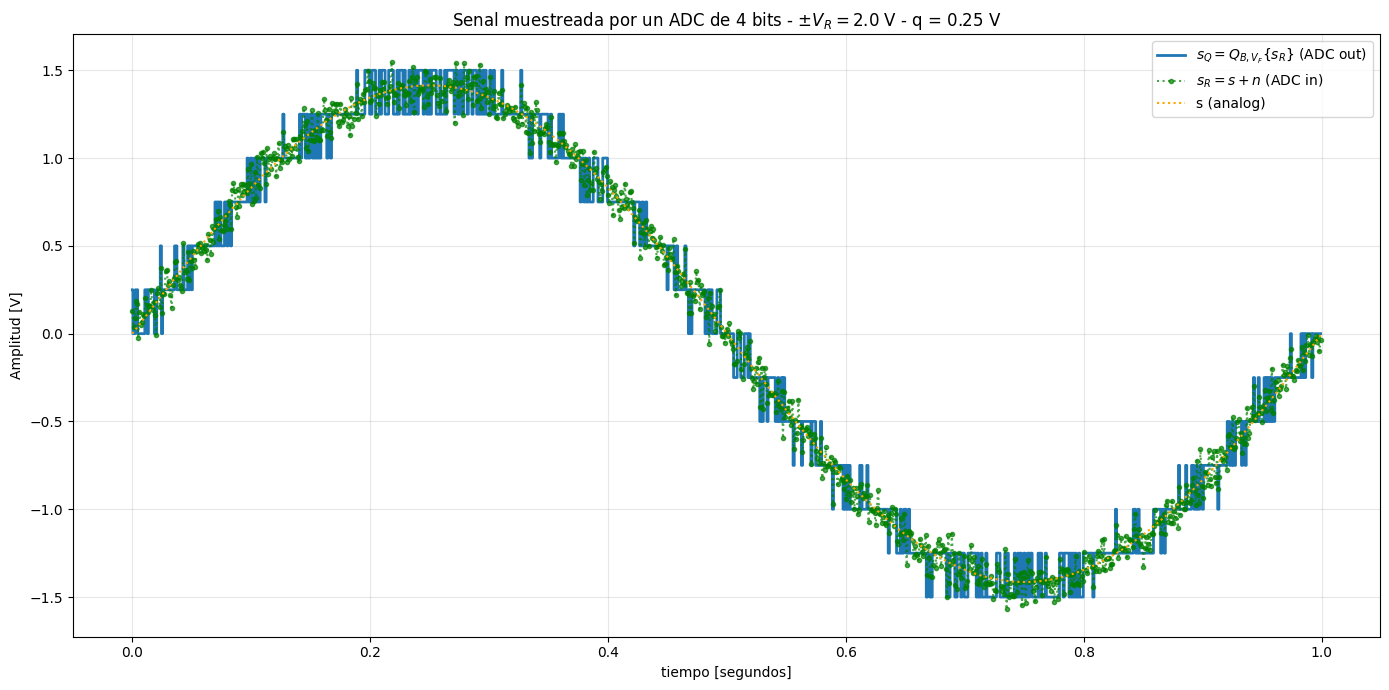

In [21]:
plt.figure(figsize=(14, 7))
plt.step(t, s_Q, where='mid', lw=2, label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(t, s_R, marker='.', linestyle=':', color='green', markersize=6, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(t, s, linestyle=':', color='orange', label='s (analog)')
plt.title(f'Senal muestreada por un ADC de {B} bits - $\\pm V_R = {V_F}$ V - q = {q} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

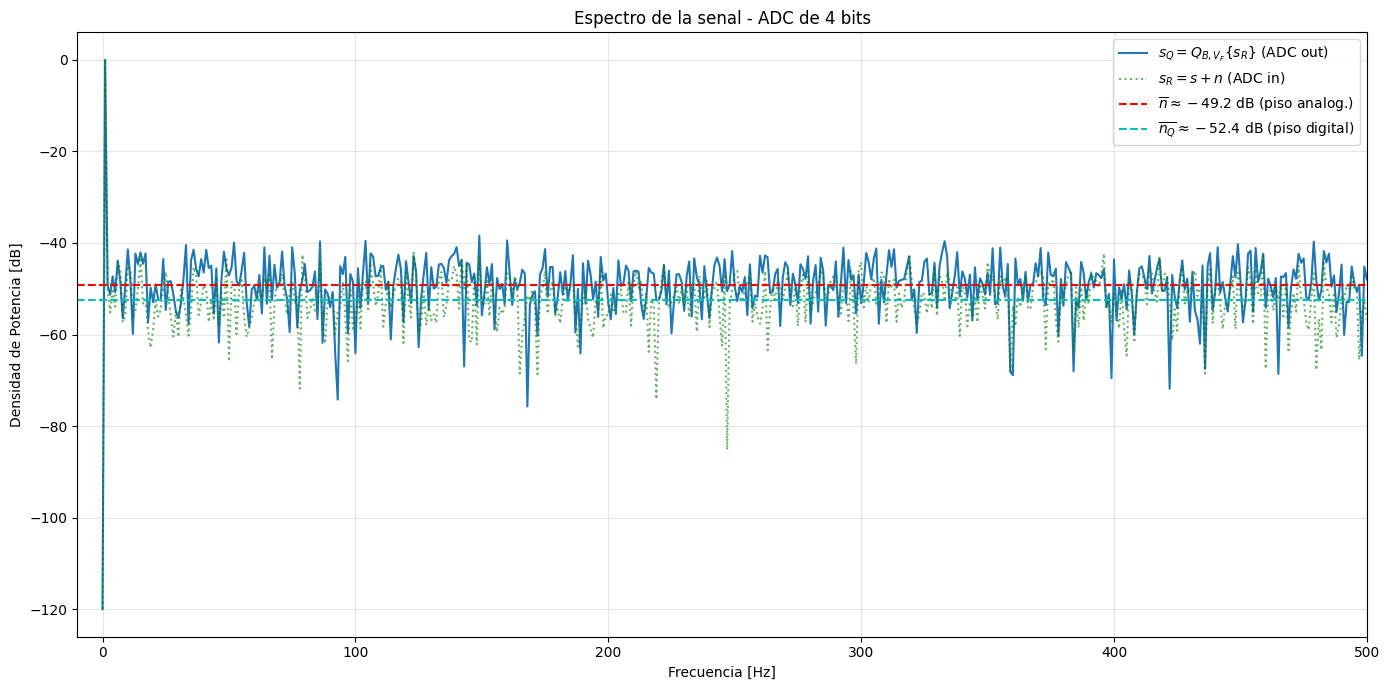

In [22]:
# densidad de pot
f_fft, Pxx_R = sig.periodogram(s_R, fs, window='boxcar', scaling='spectrum')
f_fft, Pxx_Q = sig.periodogram(s_Q, fs, window='boxcar', scaling='spectrum')

# paso a dB
Pxx_R_dB = 10 * np.log10(Pxx_R + 1e-12)
Pxx_Q_dB = 10 * np.log10(Pxx_Q + 1e-12)

# piso analogico => espectro de s_Q
# piso digital => espectro de s_R
piso_analogico_dB = np.mean(Pxx_Q_dB[3:])
piso_digital_dB   = np.mean(Pxx_R_dB[3:])

plt.figure(figsize=(14, 7))
plt.plot(f_fft, Pxx_Q_dB, label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)', color='C0')
plt.plot(f_fft, Pxx_R_dB, label=r'$s_R = s + n$ (ADC in)', color='green', alpha=0.6, linestyle=':')
plt.axhline(piso_analogico_dB, color='red', linestyle='--',
            label=f'$\\overline{{n}} \\approx {piso_analogico_dB:.1f}$ dB (piso analog.)')
plt.axhline(piso_digital_dB, color='c', linestyle='--',
            label=f'$\\overline{{n_Q}} \\approx {piso_digital_dB:.1f}$ dB (piso digital)')

plt.title(f'Espectro de la senal - ADC de {B} bits')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend(loc='upper right')
plt.xlim(-10, fs/2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

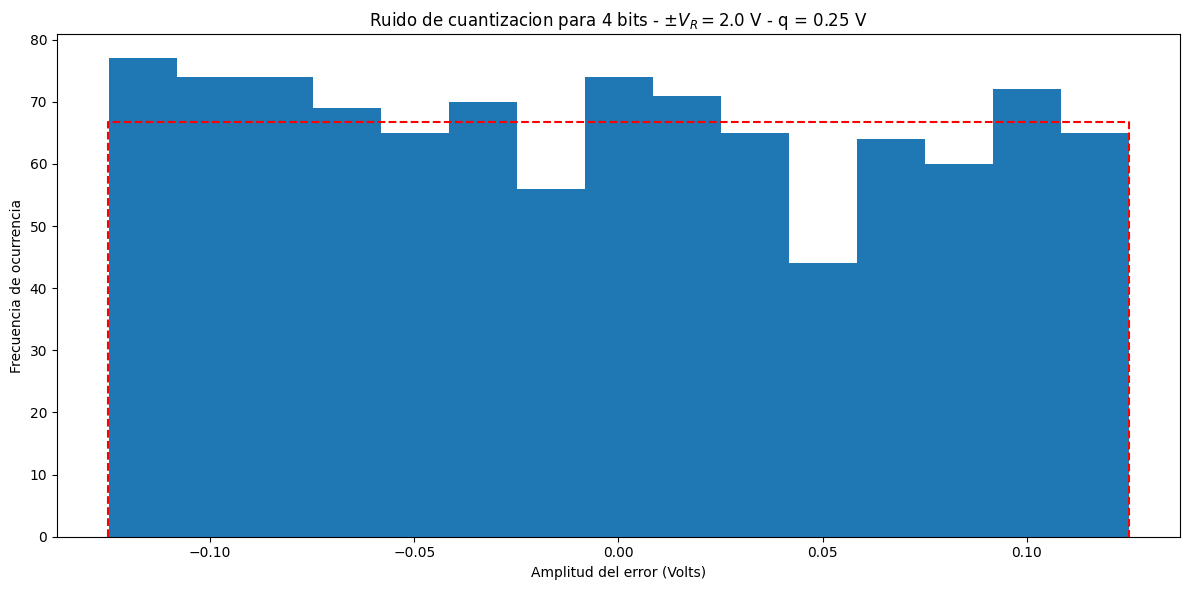

In [23]:
# hitograma del ruido
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(e_q, bins=15, density=False, color='C0')
plt.title(f'Ruido de cuantizacion para {B} bits - $\\pm V_R = {V_F}$ V - q = {q} V')

#  rectángulo teorico ideal (-q/2 y q/2)
altura_teorica = N / 15
plt.plot([-q/2, -q/2, q/2, q/2], [0, altura_teorica, altura_teorica, 0], 'r--', lw=1.5)

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Frecuencia de ocurrencia')
plt.tight_layout()
plt.show()

## Punto b)

Se analiza el efecto de variar la resolución del ADC $B \in \{4, 8, 16\}$ bits y la relación entre el ruido analógico y el ruido de cuantización $k_n \in \{1/10,\, 1,\, 10\}$.

Para cada combinación se grafica el espectro de potencia de la salida del ADC y se comparan los pisos de ruido resultantes.

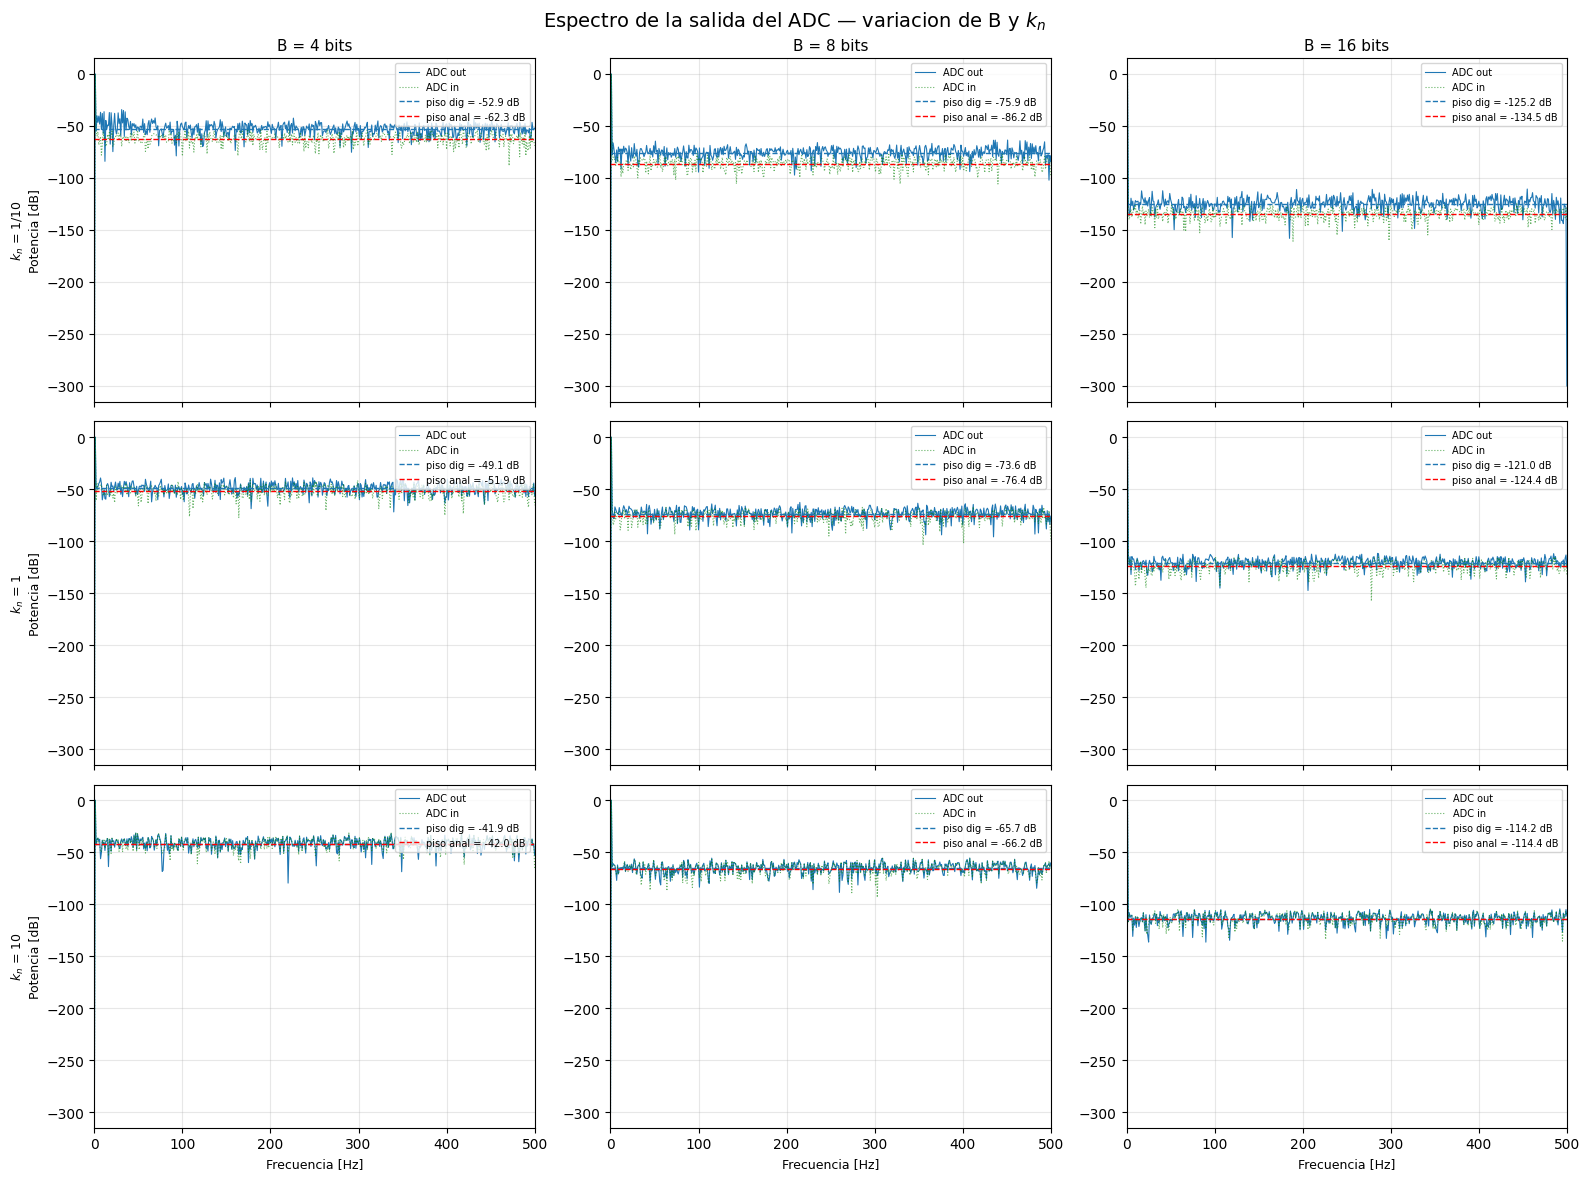

In [24]:
fs   = 1000.0
N    = 1000
f0   = fs / N
V_F  = 2.0
t    = np.arange(N) / fs

B_values  = [4, 8, 16]
kn_values = [1/10, 1, 10]
kn_labels = ['1/10', '1', '10']

np.random.seed(42)   # reproducibilidad

# senal senoidal
s = np.sqrt(2) * np.sin(2 * np.pi * f0 * t)

# unifico graficos
fig, axes = plt.subplots(len(kn_values), len(B_values),
                         figsize=(16, 12), sharex=True, sharey=False)
fig.suptitle('Espectro de la salida del ADC — variacion de B y $k_n$', fontsize=14)

for row, (kn, kn_label) in enumerate(zip(kn_values, kn_labels)):
    for col, B in enumerate(B_values):
        ax = axes[row][col]

        q      = (2 * V_F) / (2**B)
        Pq     = (q**2) / 12
        Pn     = kn * Pq
        sigma_n = np.sqrt(Pn)

        n    = np.random.normal(0, sigma_n, N)
        s_R  = s + n
        s_Q  = np.clip(np.round(s_R / q) * q, -V_F, V_F - q)

        f_fft, Pxx_Q = sig.periodogram(s_Q, fs, window='boxcar', scaling='spectrum')
        f_fft, Pxx_R = sig.periodogram(s_R, fs, window='boxcar', scaling='spectrum')
        Pxx_Q_dB = 10 * np.log10(Pxx_Q + 1e-30)
        Pxx_R_dB = 10 * np.log10(Pxx_R + 1e-30)

        piso_Q = np.mean(Pxx_Q_dB[3:])
        piso_R = np.mean(Pxx_R_dB[3:])

        ax.plot(f_fft, Pxx_Q_dB, color='C0', lw=0.8, label='ADC out')
        ax.plot(f_fft, Pxx_R_dB, color='green', lw=0.8, alpha=0.6,
                linestyle=':', label='ADC in')
        ax.axhline(piso_Q, color='C0',   linestyle='--', lw=1,
                   label=f'piso dig = {piso_Q:.1f} dB')
        ax.axhline(piso_R, color='red',  linestyle='--', lw=1,
                   label=f'piso anal = {piso_R:.1f} dB')

        ax.set_xlim(0, fs/2)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='upper right')

        if row == 0:
            ax.set_title(f'B = {B} bits', fontsize=11)
        if col == 0:
            ax.set_ylabel(f'$k_n$ = {kn_label}\nPotencia [dB]', fontsize=9)
        if row == len(kn_values) - 1:
            ax.set_xlabel('Frecuencia [Hz]', fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
# tabla de ruidos
print(f"{'B':>4} | {'kn':>6} | {'q [V]':>8} | {'Pq [dBW]':>10} | {'Pn [dBW]':>10} | "
      f"{'piso_Q [dB]':>12} | {'piso_R [dB]':>12} | {'SNR_Q [dB]':>10}")
print("-" * 90)

np.random.seed(42)
P_senal_dB = 10 * np.log10(1.0)  # energia unitaria (0 dB)

for kn, kn_label in zip(kn_values, kn_labels):
    for B in B_values:
        q       = (2 * V_F) / (2**B)
        Pq      = (q**2) / 12
        Pn      = kn * Pq
        sigma_n = np.sqrt(Pn)

        n    = np.random.normal(0, sigma_n, N)
        s_R  = s + n
        s_Q  = np.clip(np.round(s_R / q) * q, -V_F, V_F - q)

        # Piso espectral
        _, Pxx_Q = sig.periodogram(s_Q, fs, window='boxcar', scaling='spectrum')
        _, Pxx_R = sig.periodogram(s_R, fs, window='boxcar', scaling='spectrum')
        piso_Q  = np.mean(10 * np.log10(Pxx_Q[3:] + 1e-30))
        piso_R  = np.mean(10 * np.log10(Pxx_R[3:] + 1e-30))

        # SNR aprox como potencia de senal
        snr_Q = P_senal_dB - piso_Q

        print(f"{B:>4} | {kn_label:>6} | {q:>8.5f} | {10*np.log10(Pq):>10.2f} | "
              f"{10*np.log10(Pn):>10.2f} | {piso_Q:>12.2f} | {piso_R:>12.2f} | {snr_Q:>10.2f}")
    print()

   B |     kn |    q [V] |   Pq [dBW] |   Pn [dBW] |  piso_Q [dB] |  piso_R [dB] | SNR_Q [dB]
------------------------------------------------------------------------------------------
   4 |   1/10 |  0.25000 |     -22.83 |     -32.83 |       -52.87 |       -62.27 |      52.87
   8 |   1/10 |  0.01562 |     -46.92 |     -56.92 |       -75.90 |       -86.19 |      75.90
  16 |   1/10 |  0.00006 |     -95.08 |    -105.08 |      -125.22 |      -134.54 |     125.22

   4 |      1 |  0.25000 |     -22.83 |     -22.83 |       -49.11 |       -51.92 |      49.11
   8 |      1 |  0.01562 |     -46.92 |     -46.92 |       -73.57 |       -76.37 |      73.57
  16 |      1 |  0.00006 |     -95.08 |     -95.08 |      -120.99 |      -124.40 |     120.99

   4 |     10 |  0.25000 |     -22.83 |     -12.83 |       -41.86 |       -41.98 |      41.86
   8 |     10 |  0.01562 |     -46.92 |     -36.92 |       -65.73 |       -66.23 |      65.73
  16 |     10 |  0.00006 |     -95.08 |     -85.08 |      -11

#### Efecto de B

Cada bit adicional reduce el paso de cuantizacion a la mitad: $q = \frac{2V_F}{2^B}$, lo que hace que la potencia de cuantizacion $P_q = q^2/12$ caiga **6 dB por bit**. En el espectro esto se observa como una bajada del piso de ruido digital (~6 dB por cada bit extra). Con B = 16 bits el ruido de cuantizacion es tan pequeno que deja de ser el factor limitante en casi cualquier condicion.

#### Efecto de $k_n$ (rel ruido analogico / cuantizacion)

- **$k_n = 1/10$**: el ruido analogico es mucho menor que el de cuantizacion. El piso espectral del ADC queda dominado por la cuantizacion. Aumentar B mejora significativamente el SNR.
- **$k_n = 1$** (caso del punto a): ruido analogico y de cuantizacion son comparables. El piso digital queda ~3 dB sobre el piso analogico. Este fue el caso estudiado en a).
- **$k_n = 10$**: el ruido analogico domina ampliamente. El piso digital se aproxima al analogico y aumentar B ya no mejora el SNR, porque el cuello de botella es el ruido de entrada, no la cuantizacion.

#### Comparacion con el punto a)

En a) (B = 4, $k_n = 1$) el piso de ruido digital es notoriamente alto debido al paso de cuantizacion grueso ($q = 0.125$ V). Al pasar a B = 8 con el mismo $k_n = 1$ el piso baja ~24 dB, y con B = 16 otros ~48 dB adicionales respecto del caso original. Sin embargo, con $k_n = 10$ todos los valores de B convergen al mismo piso, mostrando que la resolucion del ADC solo importa cuando el ruido analogico no enmascara el error de cuantizacion.

## Relacion entre B bits y SNR


Con $q = 2V_F/2^B$, la potencia de ruido de cuantizacion es:

$$P_q = \frac{q^2}{12} = \frac{V_F^2}{3 \cdot 4^B}$$

El ruido analogico es $P_n = k_n \cdot P_q$, por lo que el ruido total es $(1+k_n)\,P_q$. Para senal de potencia unitaria ($P_s = 1$ W) y $V_F = 2$ V:

$$\text{SNR} = \frac{P_s}{(1+k_n)\,P_q} = \frac{3 \cdot 4^B}{4\,(1+k_n)}$$

$$\boxed{\text{SNR [dB]} \approx 6.02\,B - 1.25 - 10\log_{10}(1+k_n)}$$

La pendiente es siempre ~6 dB por bit. El factor $k_n$ solo desplaza la curva verticalmente (offset), no cambia la pendiente, porque el ruido analogico tambien depende de $B$ a traves de $P_q$.

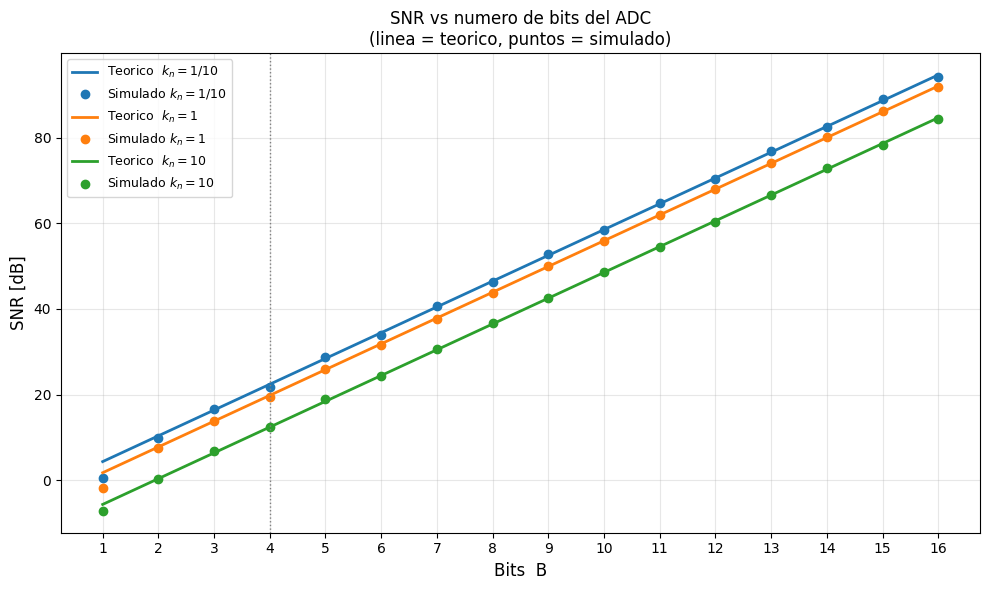

Pendiente empirica SNR vs B (dB/bit):
  kn = 1/10  →  6.12 dB/bit  (teorico: 6.02 dB/bit)
  kn =    1  →  6.11 dB/bit  (teorico: 6.02 dB/bit)
  kn =   10  →  6.04 dB/bit  (teorico: 6.02 dB/bit)


In [26]:
# params

fs = 1000.0
N  = 1000
f0 = fs / N 
V_F = 2.0
t = np.arange(N) / fs
s = np.sqrt(2) * np.sin(2 * np.pi * f0 * t)

B_range   = np.arange(1, 17) #para ir de  B = 1..16 bits
kn_values = [1/10, 1, 10]
kn_labels = ['1/10', '1', '10']
colors    = ['C0', 'C1', 'C2']

np.random.seed(0)

# SNR empirico

# bin de la fundamental
bin_s = 1

snr_emp = {kn: [] for kn in kn_values}

for B in B_range:
    q       = (2 * V_F) / (2**B)
    Pq      = (q**2) / 12
    for kn in kn_values:
        sigma_n = np.sqrt(kn * Pq)
        n       = np.random.normal(0, sigma_n, N)
        s_Q     = np.clip(np.round((s + n) / q) * q, -V_F, V_F - q)

        _, Pxx = sig.periodogram(s_Q, fs, window='boxcar', scaling='spectrum')
        P_sig   = Pxx[bin_s]
        P_noise = np.sum(Pxx) - P_sig - Pxx[0]   # quita DC y fundamental
        snr_emp[kn].append(10 * np.log10(P_sig / (P_noise + 1e-30)))

# SNR teorico

B_fine = np.linspace(1, 16, 200)

fig, ax = plt.subplots(figsize=(10, 6))

for kn, label, color in zip(kn_values, kn_labels, colors):
    snr_teo = 6.02 * B_fine - 1.25 - 10 * np.log10(1 + kn)
    ax.plot(B_fine, snr_teo, color=color, lw=2,
            label=f'Teorico  $k_n={label}$')
    ax.plot(B_range, snr_emp[kn], 'o', color=color, markersize=6,
            label=f'Simulado $k_n={label}$')

# para resaltar caso a) =>  B=4, kn=1
ax.axvline(4, color='gray', linestyle=':', lw=1)
ax.set_xlabel('Bits  B', fontsize=12)
ax.set_ylabel('SNR [dB]', fontsize=12)
ax.set_title('SNR vs numero de bits del ADC\n(linea = teorico, puntos = simulado)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(B_range)
plt.tight_layout()
plt.show()

# verifico pendiente empírica ~6 dB/bit

print("Pendiente empirica SNR vs B (dB/bit):")
for kn, label in zip(kn_values, kn_labels):
    vals = np.array(snr_emp[kn])
    slope = np.polyfit(B_range, vals, 1)[0]
    print(f"  kn = {label:>4}  →  {slope:.2f} dB/bit  (teorico: 6.02 dB/bit)")

## Efecto del aliasing en el muestreo

### Teorema de Nyquist-Shannon

Al muestrear una senal continua a $f_s$ Hz, solo se pueden representar correctamente frecuencias $f < f_s/2$ (frecuencia de Nyquist). Si el espectro de la senal analogica contiene componentes por encima de $f_s/2$, el muestreo provoca que esas componentes se repliquen (aliaseen) dentro del rango $[0, f_s/2]$ segun:

$$f_{\text{alias}} = \left| f_0 - \text{round}\!\left(\frac{f_0}{f_s}\right) \cdot f_s \right|$$

En la simulacion se generan senales analogicas a distintas frecuencias (por encima y por debajo de Nyquist), se muestrean a $f_s = 1000$ Hz y se observa donde aparece la componente en el espectro digital.

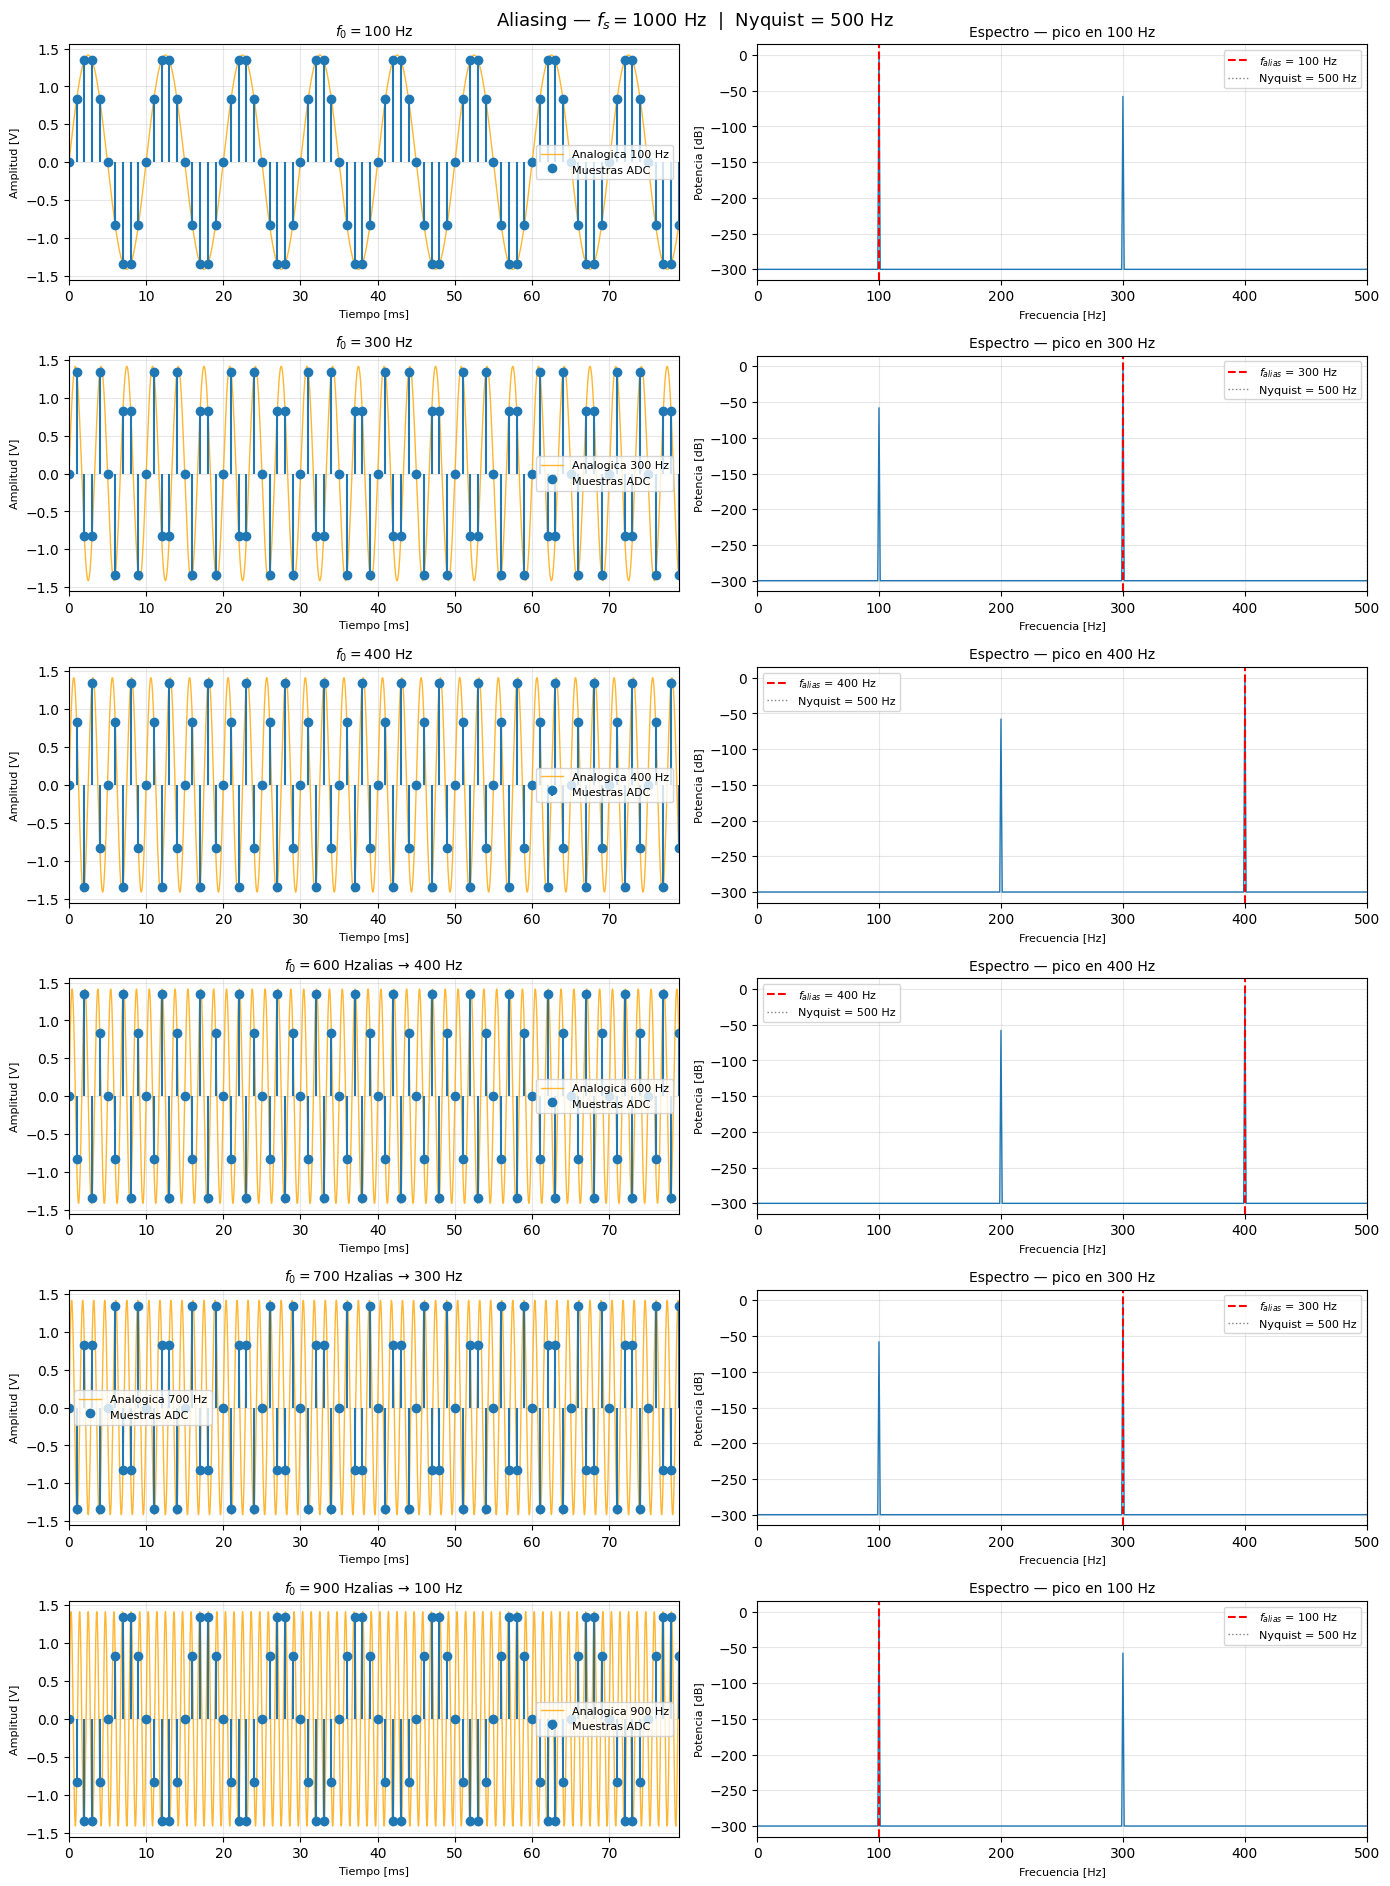

In [27]:
fs = 1000.0
N = 1000
V_F = 2.0
B = 8
q = (2 * V_F) / (2**B)

# senales analogicas a evaluar
f_test = [100, 300, 400, 600, 700, 900]

# senal continua simulada a fs_hi >> fs para poder observar la forma real
fs_hi = 100 * fs  # 100 kHz
t_hi = np.arange(int(N * fs_hi / fs)) / fs_hi   # misma duracion que N muestras

# grafico tiempo + espectro para cada f_test

fig, axes = plt.subplots(len(f_test), 2, figsize=(14, 3.2 * len(f_test)))
fig.suptitle(f'Aliasing — $f_s = {fs:.0f}$ Hz  |  Nyquist = {fs/2:.0f} Hz', fontsize=13)

for i, f0 in enumerate(f_test):
    # senal analogica
    s_hi = np.sqrt(2) * np.sin(2 * np.pi * f0 * t_hi)

    # muestras digitales
    decimation = int(fs_hi / fs)
    t_dig = np.arange(N) / fs
    s_dig = s_hi[::decimation][:N]

    # cuantizacion (sin ruido analogico para ver solo el aliasing)
    s_Q = np.clip(np.round(s_dig / q) * q, -V_F, V_F - q)

    # espectro
    f_fft, Pxx = sig.periodogram(s_Q, fs, window='boxcar', scaling='spectrum')
    Pxx_dB = 10 * np.log10(Pxx + 1e-30)

    # alias teorico
    f_alias = abs(f0 - round(f0 / fs) * fs)

    # grafico de tiempo
    ax_t = axes[i][0]
    n_show = min(80, N)
    t_show = t_hi[:n_show * decimation]
    ax_t.plot(t_show * 1000, s_hi[:n_show * decimation],
              color='orange', lw=1, label=f'Analogica {f0} Hz', alpha=0.8)
    ax_t.stem(t_dig[:n_show] * 1000, s_Q[:n_show],
              linefmt='C0-', markerfmt='C0o', basefmt=' ',
              label='Muestras ADC')
    ax_t.set_xlim(0, t_dig[n_show - 1] * 1000)
    ax_t.set_ylabel('Amplitud [V]', fontsize=8)
    ax_t.set_xlabel('Tiempo [ms]', fontsize=8)
    title_t = f'$f_0 = {f0}$ Hz'
    if f0 > fs / 2:
        title_t += f'alias → {f_alias:.0f} Hz'
    ax_t.set_title(title_t, fontsize=10)
    ax_t.legend(fontsize=8)
    ax_t.grid(True, alpha=0.3)

    # espectro
    ax_f = axes[i][1]
    ax_f.plot(f_fft, Pxx_dB, color='C0', lw=1)
    ax_f.axvline(f_alias, color='red', linestyle='--', lw=1.5,
                 label=f'$f_{{alias}}$ = {f_alias:.0f} Hz')
    ax_f.axvline(fs / 2, color='gray', linestyle=':', lw=1,
                 label=f'Nyquist = {fs/2:.0f} Hz')
    ax_f.set_xlim(0, fs / 2)
    ax_f.set_xlabel('Frecuencia [Hz]', fontsize=8)
    ax_f.set_ylabel('Potencia [dB]', fontsize=8)
    ax_f.set_title(f'Espectro — pico en {f_alias:.0f} Hz', fontsize=10)
    ax_f.legend(fontsize=8)
    ax_f.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

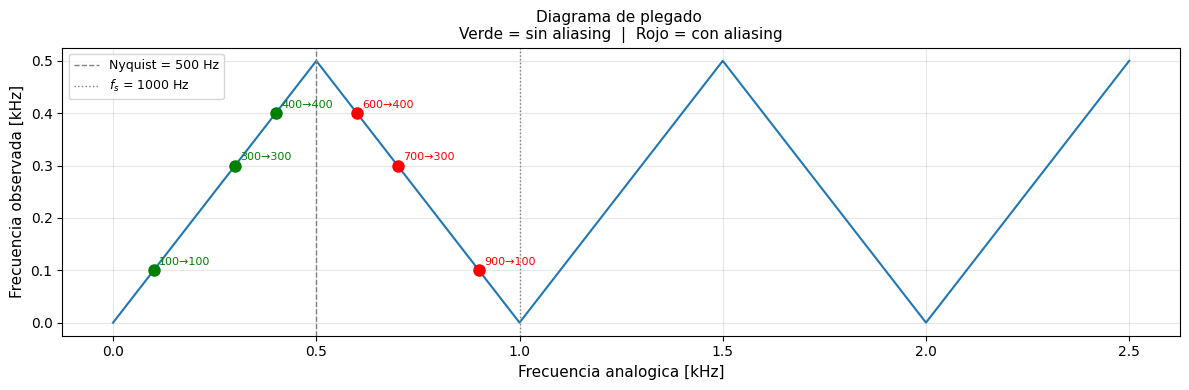

In [28]:
# diagrama de plegado
# para mostrar como las frecuencias analogicas se mapean
# al intervalo [0, fs/2] luego del muestreo

f_analog = np.linspace(0, 2.5 * fs, 5000)

def alias_freq(f, fs):
    """Frecuencia observada tras muestrear a fs."""
    f_mod = f % fs # reduccion modular
    return np.where(f_mod <= fs/2, f_mod, fs - f_mod)

f_obs = alias_freq(f_analog, fs)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(f_analog / 1000, f_obs / 1000, color='C0', lw=1.5)
ax.axvline(fs / 2 / 1000, color='gray', linestyle='--', lw=1, label=f'Nyquist = {fs/2:.0f} Hz')
ax.axvline(fs / 1000,     color='gray', linestyle=':',  lw=1, label=f'$f_s$ = {fs:.0f} Hz')

# marco los ejemplos simulados
for f0 in f_test:
    fa = alias_freq(np.array([float(f0)]), fs)[0]
    color = 'green' if f0 <= fs/2 else 'red'
    ax.plot(f0/1000, fa/1000, 'o', color=color, markersize=8, zorder=5)
    ax.annotate(f'{f0}→{fa:.0f}', (f0/1000, fa/1000),
                textcoords='offset points', xytext=(4, 4), fontsize=8, color=color)

ax.set_xlabel('Frecuencia analogica [kHz]', fontsize=11)
ax.set_ylabel('Frecuencia observada [kHz]', fontsize=11)
ax.set_title('Diagrama de plegado \nVerde = sin aliasing  |  Rojo = con aliasing', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Simulaciones

| $f_0$ analogica | $f_{\text{alias}}$ observada | Observacion |
|:-:|:-:|:--|
| 100 Hz | 100 Hz | Sin aliasing ($f_0 < f_s/2$) |
| 300 Hz | 300 Hz | Sin aliasing |
| 400 Hz | 400 Hz | Sin aliasing (justo bajo Nyquist) |
| **600 Hz** | **400 Hz** | **Aliasing**: $1000 - 600 = 400$ Hz |
| **700 Hz** | **300 Hz** | **Aliasing**: $1000 - 700 = 300$ Hz |
| **900 Hz** | **100 Hz** | **Aliasing**: $1000 - 900 = 100$ Hz |

La senal de 700 Hz muestreada a 1 kHz es indistinguible de una senal de 300 Hz. En el dominio del tiempo las muestras coinciden exactamente.

#### Diagrama de plegado

El diagrama de plegado muestra visualmente el patron de triangulo que forman las frecuencias observadas y las frecuencias analogicas se reflejan en los multiplos de $f_s/2$. La zona segura es el triangulo entre 0 y $f_s/2$.

#### Filtro anti-aliasing

Para evitar el aliasing se debe colocar un filtro pasa-bajos antes del ADC que elimine todas las componentes por encima de $f_s/2$. Sin ese filtro, cualquier senal de alta frecuencia presente en la entrada se solapa con el espectro util y no puede ser eliminada posteriormente.